In [1]:
from pathlib import Path
PROJECT_FOLDER = Path.cwd().parents[1]

import yaml
with open('config.yaml', 'r', encoding='utf-8') as f: 
    config = yaml.safe_load(f)

import sys, os
sys.path.append(PROJECT_FOLDER)
os.chdir(PROJECT_FOLDER)

print(sys.path[-1])
print(config)

/Users/sam/NUS/NUSC-ISC-FootballAnalysis
{'experiment_name': 'ex03_gaussian_heatmap', 'pitch_calibration_dataset': {'img_folder': 'data/calibration', 'width': 640, 'height': 360, 'centered': False, 'keypoint_only': False, 'selected_idxs': [0, 3, 4, 5]}, 'pitch_calibration_datamodule': {'batch_size': 8, 'num_workers': 8, 'persistent_workers': True}, 'gaussian_heatmap_model': 'wandb_logs/ISC-Football/gwqhfk3g/checkpoints/epoch=2-step=192.ckpt', 'spiideo_dataset': {'base_folder': 'data/SpiideoSynLoc', 'width': 3840, 'height': 2160, 'n_crops': 16, 'crop_width': 512, 'crop_height': 512, 'n_limit': 4}, 'spiideo_datamodule': {'batch_size': 4, 'num_workers': 8, 'persistent_workers': True}, 'trainer': {'accelerator': 'gpu', 'max_epochs': 32}}


In [2]:
import cv2
from tqdm import tqdm
import itertools

import torch
from torch.utils.data import DataLoader
from torchvision.utils import make_grid

import numpy as np
import matplotlib.pyplot as plt
import random
import requests
from PIL import Image

from dataobjects.pitch import Pitch
from datamodules.spiideo import SpiideoWithMetadataDataModule, SpiideoDatasetArgs
from datamodules.calibration.calibration import CalibrationDataModule, CalibrationDatasetArgs
from datamodules.base_datamodule import BaseDataModuleArgs
from datamodules.spiideo.gaussian import Spiideo2DGaussianMaskDataModule, Spiideo2DGaussianMaskDatasetArgs
from models.base.unet_heatmap import UNetHeatmap
from losses.focal_loss import FocalLoss

from ultralytics import YOLO
from transformers import DetrImageProcessor, DetrForObjectDetection
from transformers import SamModel, SamProcessor
from sklearn.cluster import MiniBatchKMeans

/Users/sam/miniconda3/envs/ISC-Football/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
%reload_ext autoreload
%autoreload 2

In [4]:
spiideo_gaussian_data_module = Spiideo2DGaussianMaskDataModule(
    Spiideo2DGaussianMaskDatasetArgs(**config['spiideo_dataset']), 
    BaseDataModuleArgs(**config['spiideo_datamodule'])
)

In [5]:
gaussian_ds = spiideo_gaussian_data_module.dataset('mini')
gaussian_dataloader = DataLoader(gaussian_ds, batch_size=16)
gaussian_dataloader

In [6]:
loss_fn = FocalLoss(alpha=0.90, gamma=1e-4)

img.shape  =  torch.Size([16, 1, 512, 512])
mask.shape =  torch.Size([16, 1, 512, 512])
FocalLoss with original and black mask:  tensor(0.0359)
FocalLoss with original and white mask:  tensor(0.3414)
FocalLoss with original and random mask:  tensor(0.0545)
Output for display:
img.shape  =  torch.Size([2058, 2058, 3])
mask.shape =  torch.Size([2058, 2058, 3])


/var/folders/sb/bsmqpwg91sn_3fvr5z519y5c0000gn/T/ipykernel_75313/4000084749.py:29: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


img.shape  =  torch.Size([16, 1, 512, 512])
mask.shape =  torch.Size([16, 1, 512, 512])
FocalLoss with original and black mask:  tensor(0.0158)
FocalLoss with original and white mask:  tensor(0.3436)
FocalLoss with original and random mask:  tensor(0.0519)
img.shape  =  torch.Size([16, 1, 512, 512])
mask.shape =  torch.Size([16, 1, 512, 512])
FocalLoss with original and black mask:  tensor(0.0571)
FocalLoss with original and white mask:  tensor(0.3391)
FocalLoss with original and random mask:  tensor(0.0572)
img.shape  =  torch.Size([16, 1, 512, 512])
mask.shape =  torch.Size([16, 1, 512, 512])
FocalLoss with original and black mask:  tensor(0.0298)
FocalLoss with original and white mask:  tensor(0.3421)
FocalLoss with original and random mask:  tensor(0.0538)
Count: 3


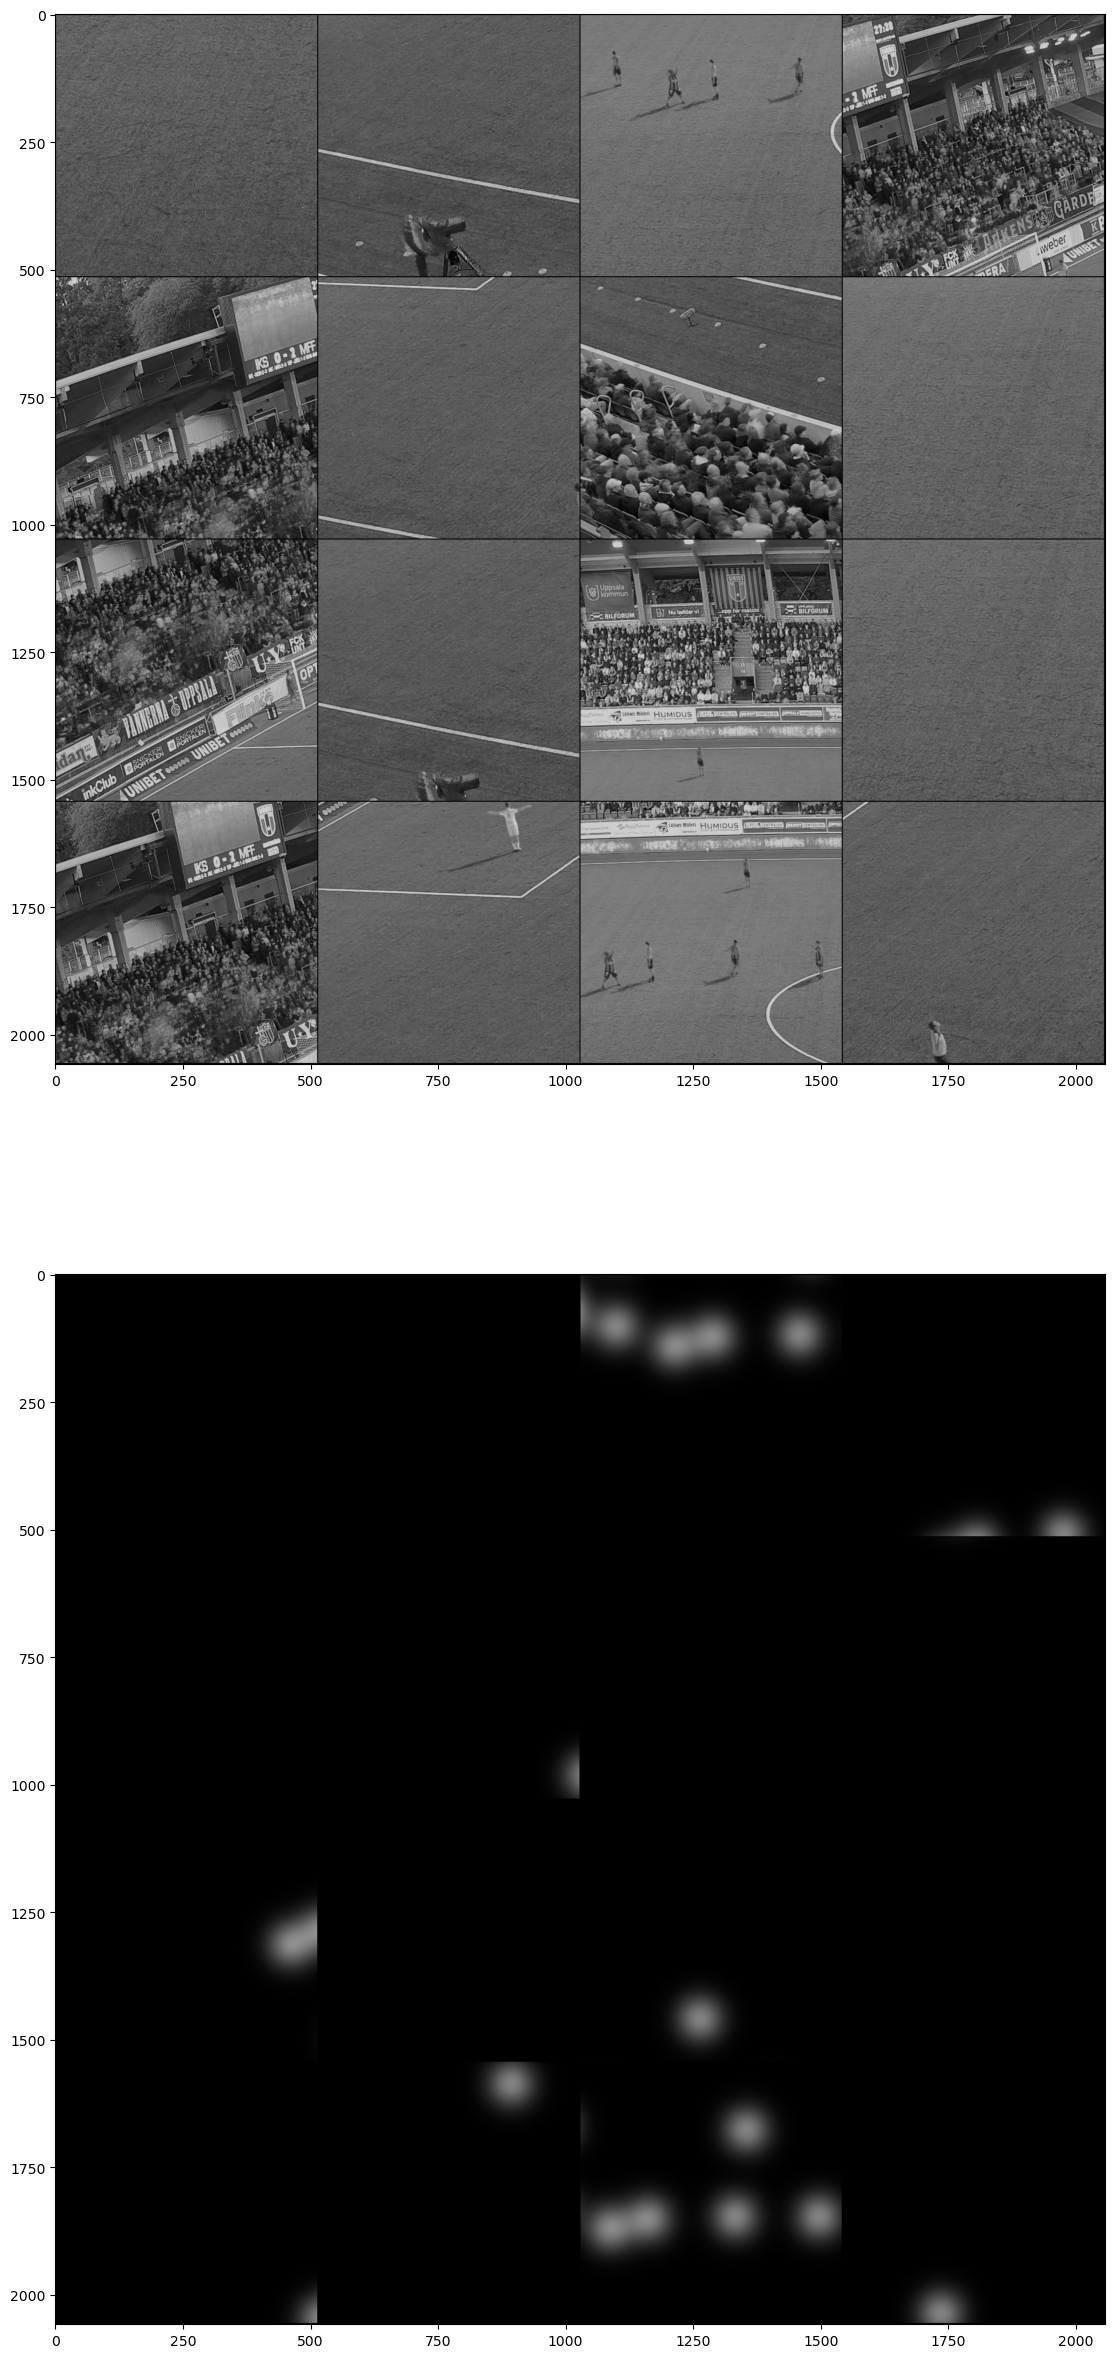

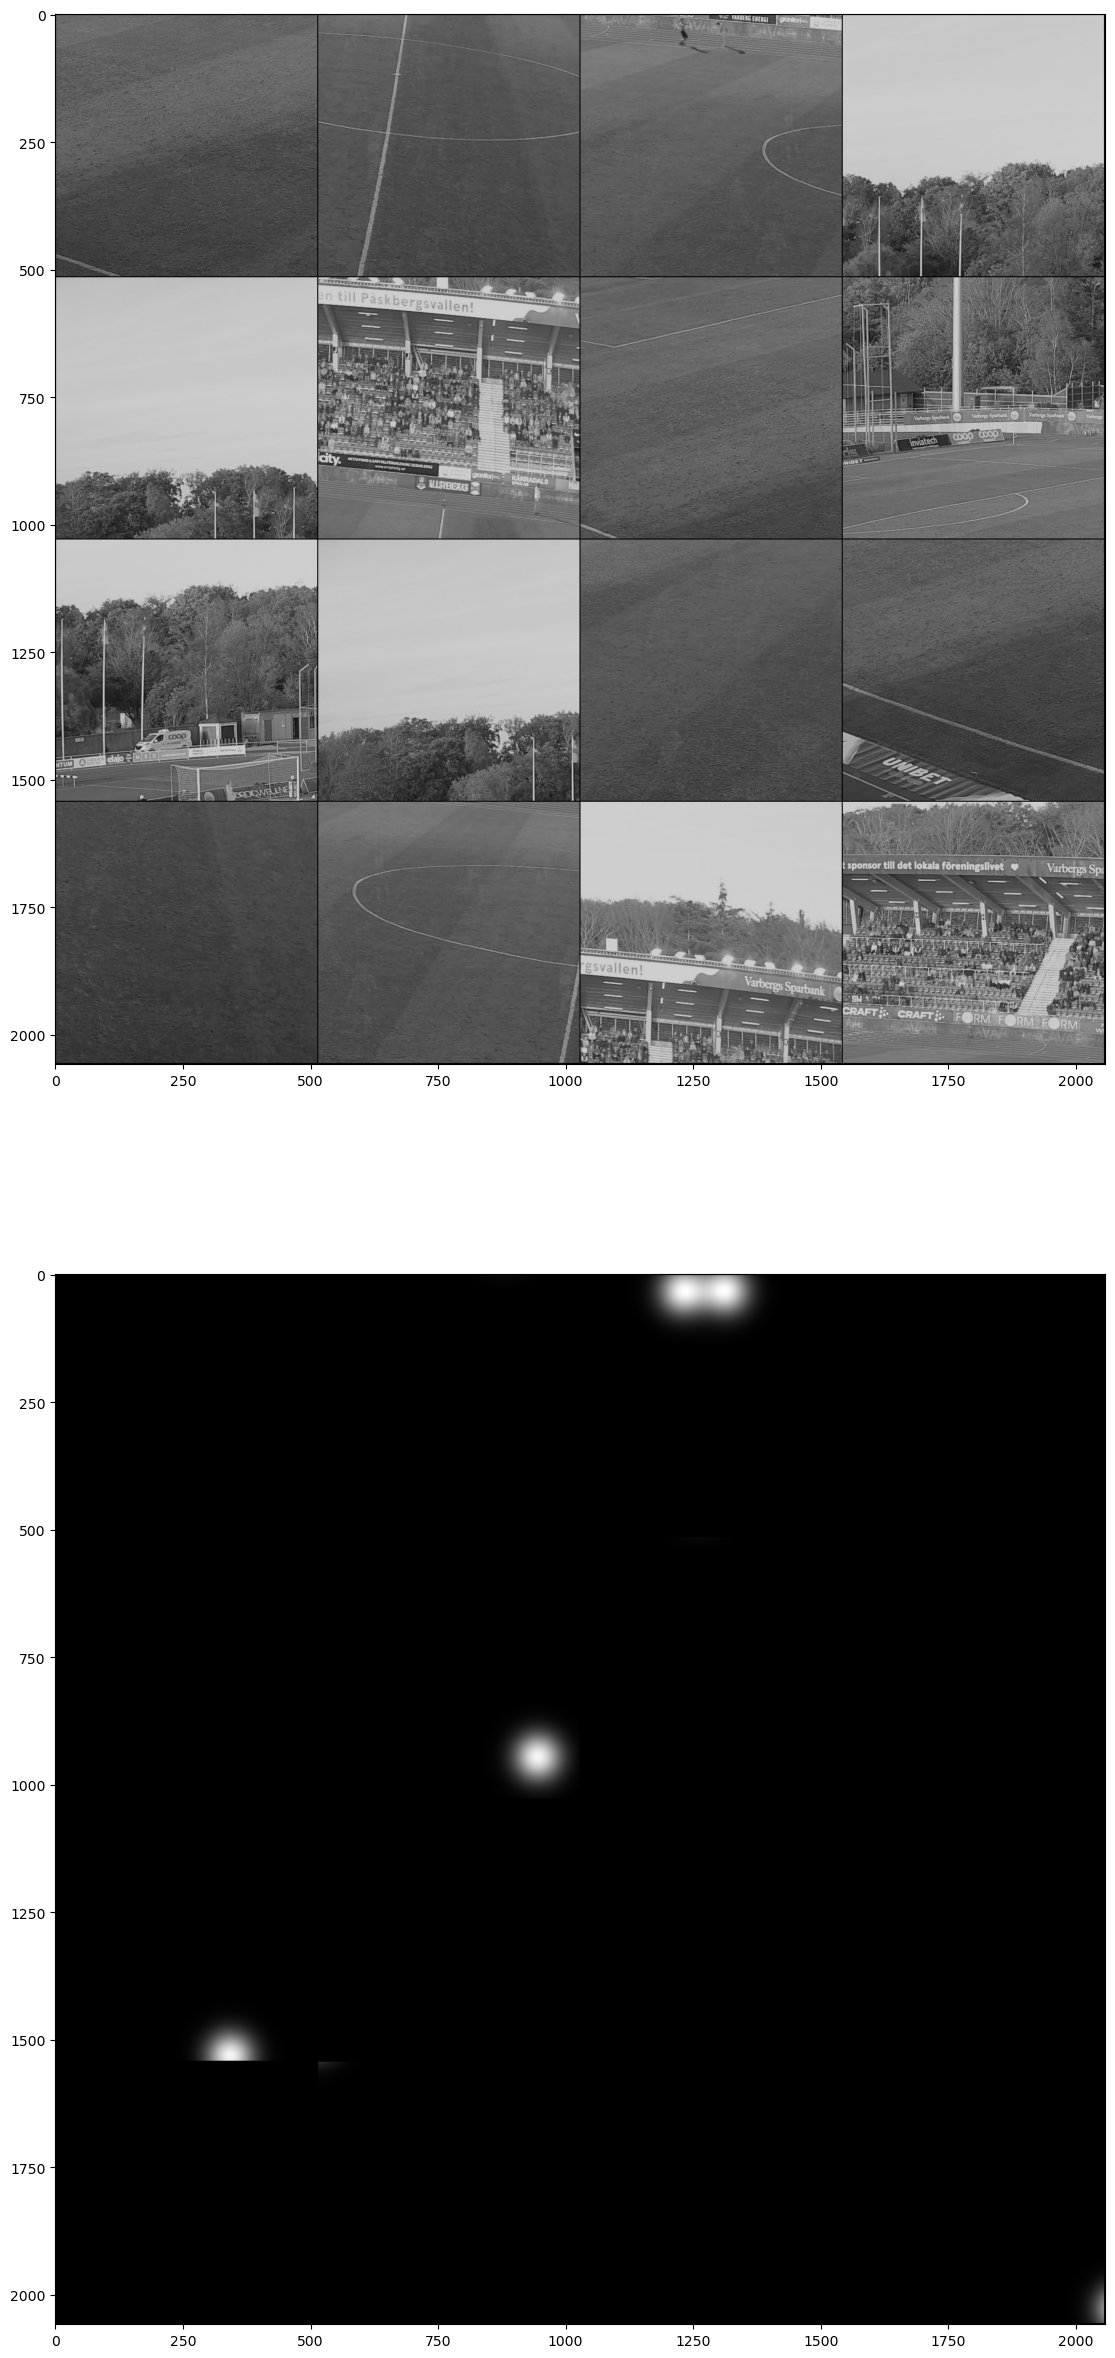

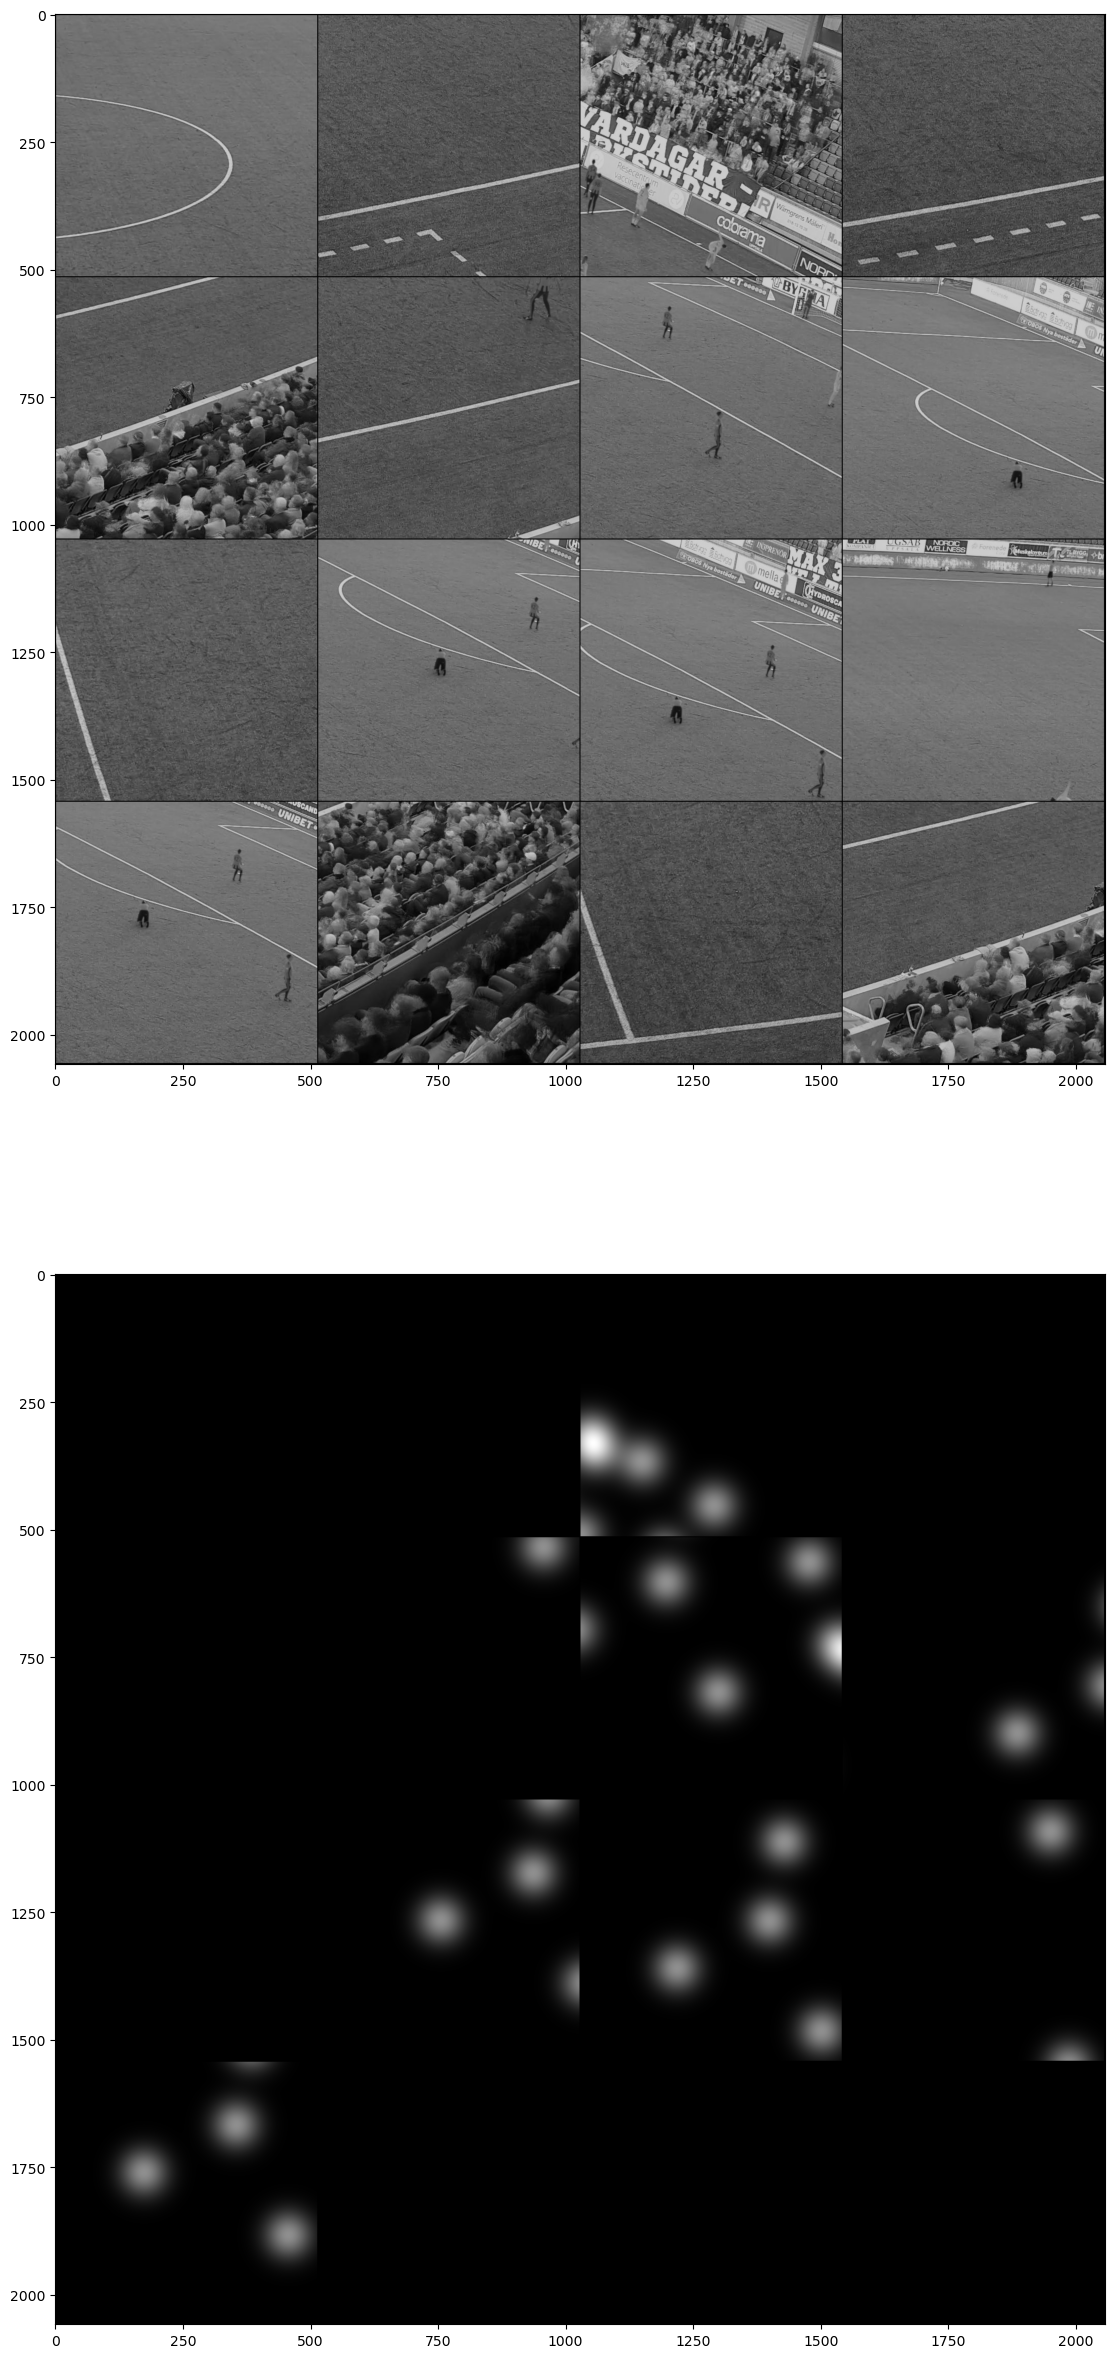

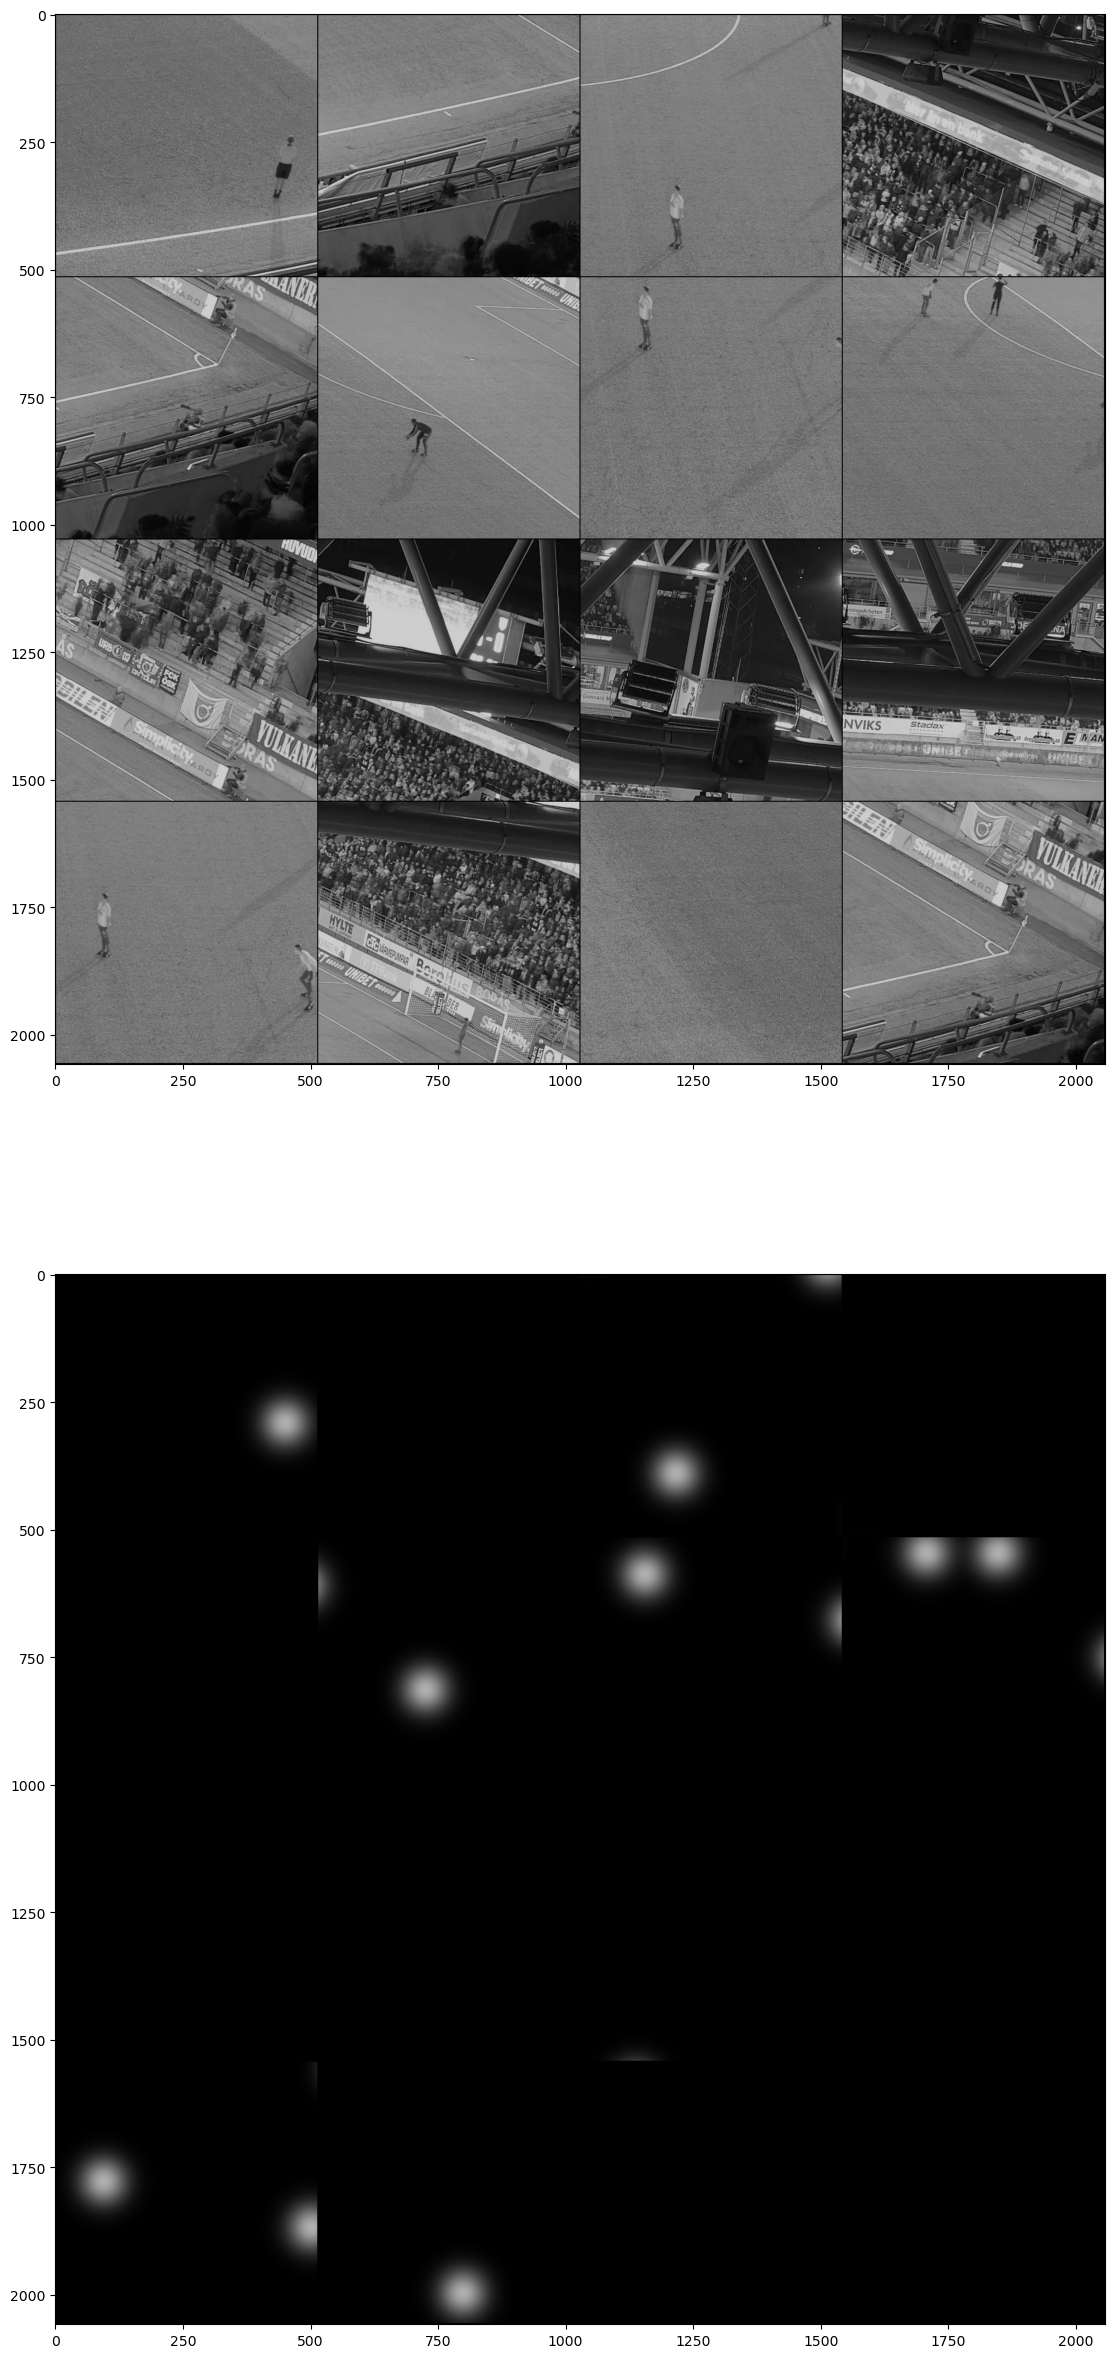

In [7]:
for idx, batch in enumerate(gaussian_dataloader):
    img, mask = batch
    if True or idx == 0:
        print('img.shape  = ', img.shape)
        print('mask.shape = ', mask.shape)

        loss_0 = loss_fn(torch.zeros_like(mask), mask)
        loss_1 = loss_fn(torch.ones_like(mask), mask)
        loss_r = loss_fn(torch.rand_like(mask), mask)

        print('FocalLoss with original and black mask: ', loss_0)
        print('FocalLoss with original and white mask: ', loss_1)
        print('FocalLoss with original and random mask: ', loss_r)

    def gridify(img):
        return make_grid(img, nrow=4).permute((1, 2, 0)).cpu()

    img = gridify(img)
    mask = gridify(mask)

    if idx == 0:
        print('Output for display:')
        print('img.shape  = ', img.shape)
        print('mask.shape = ', mask.shape)

    fig, ax = plt.subplots(nrows=2, figsize=(40,30))
    ax[0].imshow(img, cmap='gray')
    ax[1].imshow(mask, cmap='gray')
    fig.show()

print('Count:', idx)

In [8]:
img, mask = next(iter(gaussian_dataloader))


In [ ]:
alphas = np.arange(0.05, 1.01, 0.05)
gammas = np.arange(0.1, 5.1, 0.1)
losses_0 = np.zeros(shape=(len(alphas), len(gammas)))
losses_1 = np.zeros(shape=(len(alphas), len(gammas)))

for idx, alpha in tqdm(enumerate(alphas)):
    for jdx, gamma in enumerate(gammas):
        loss_fn = FocalLoss(alpha=alpha, gamma=gamma)
        loss_0 = loss_fn(torch.zeros_like(mask), mask)
        loss_1 = loss_fn(torch.ones_like(mask), mask)

        losses_0[idx][jdx] = loss_0
        losses_1[idx][jdx] = loss_1

plt.imshow(losses_0)
plt.imshow(losses_1)
plt.show()

1it [00:17, 17.47s/it]

/var/folders/sb/bsmqpwg91sn_3fvr5z519y5c0000gn/T/ipykernel_66451/2578098512.py:4: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


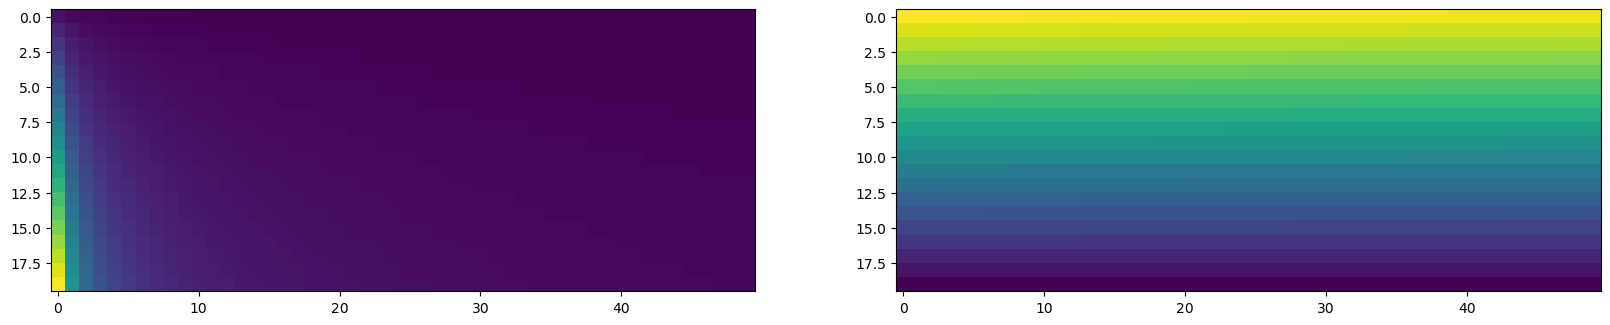

In [ ]:
fig, axes = plt.subplots(ncols=2, figsize=(20, 10))
axes[0].imshow(losses_0)
axes[1].imshow(losses_1)
fig.show()

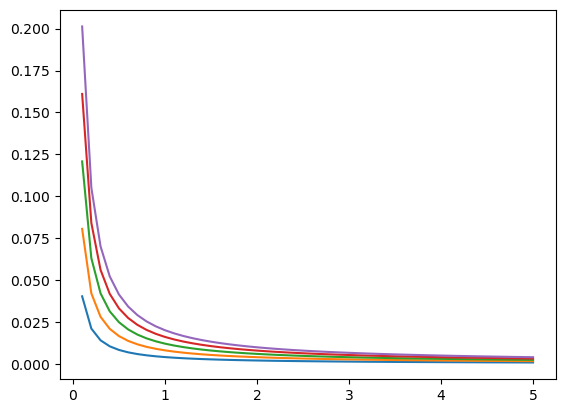

In [ ]:
for idx in range(5):
    plt.plot(gammas, losses_0[idx])